# LoRa Through Multipath and Doppler with Sionna PHY

This tutorial is the bridge from the ideal AWGN experiment to a moving UAV radio link. It keeps the LoRa chirp transmitter and FFT-bin receiver visible, while Sionna PHY converts a continuous multipath channel impulse response into time-varying discrete taps and applies those taps to the waveform.

We do not use Sionna RT yet. RT answers where paths come from in a specific 3D scene. This notebook first answers what path delay and Doppler do to one chirp.

## 1. The model boundary

The signal chain is:

~~~text
LoRa symbol -> chirp samples -> multipath and Doppler -> AWGN -> dechirp -> FFT peak
~~~

For paths indexed by p, the complex baseband channel is

$$h(t,\tau)=\sum_p a_p e^{j2\pi f_{D,p}t}\delta(\tau-\tau_p).$$

Sionna PHY converts the path gains and delays into sampled channel taps. A later RT tutorial can replace the hand-selected values of $a_p$ and $\tau_p$ with paths computed from buildings and terrain.

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from sionna.phy.channel import ApplyTimeChannel, cir_to_time_channel

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
C = 299_792_458.0
FC_HZ = 2.44e9
BW_HZ = 812_500.0

# A transparent three-path teaching channel: LoS plus two weaker reflections.
PATH_DELAYS_S = torch.tensor([0.0, 0.60e-6, 1.80e-6], dtype=torch.float32, device=DEVICE)
PATH_POWERS_DB = torch.tensor([0.0, -6.0, -10.0], dtype=torch.float32, device=DEVICE)
PATH_DIRECTIONS = torch.tensor([1.0, 0.35, -0.65], dtype=torch.float32, device=DEVICE)

L_MIN = -6
L_MAX = int(np.ceil(float(PATH_DELAYS_S.max().cpu()) * BW_HZ)) + 6
L_TOT = L_MAX - L_MIN + 1

print(f"device: {DEVICE}")
print(f"sample/chip interval: {1e6 / BW_HZ:.3f} us")
print(f"channel lags: {L_MIN} through {L_MAX} ({L_TOT} taps)")

device: cuda:0
sample/chip interval: 1.231 us
channel lags: -6 through 8 (15 taps)


## 2. Delay and Doppler scales

Carrier wavelength is $\lambda=c/f_c$, and the maximum radial Doppler magnitude is

$$f_D=\frac{v}{\lambda}=\frac{vf_c}{c}.$$

The LoRa FFT-bin spacing after dechirping is the symbol rate $R_s=BW/2^{SF}$. A useful warning ratio is $f_D/R_s$. When it approaches a substantial fraction of one bin, an uncompensated detector can lose peak energy or select a neighboring symbol.

speed | maximum Doppler
    0 m/s |      0.0 Hz
    5 m/s |     40.7 Hz
   10 m/s |     81.4 Hz
   20 m/s |    162.8 Hz
   30 m/s |    244.2 Hz
   40 m/s |    325.6 Hz


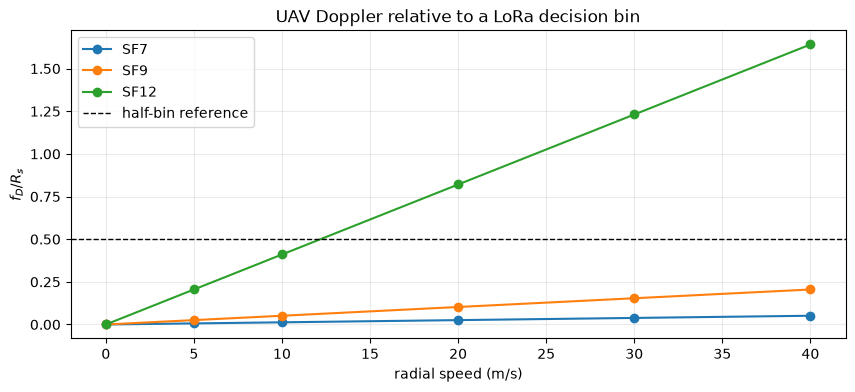

In [9]:
speeds_mps = np.array([0, 5, 10, 20, 30, 40])
doppler_hz = speeds_mps * FC_HZ / C

print("speed | maximum Doppler")
for speed, fd in zip(speeds_mps, doppler_hz):
    print(f"{speed:>5.0f} m/s | {fd:>8.1f} Hz")

fig, ax = plt.subplots()
for sf in (7, 9, 12):
    bin_spacing_hz = BW_HZ / (1 << sf)
    ax.plot(speeds_mps, doppler_hz / bin_spacing_hz, marker="o", label=f"SF{sf}")
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="half-bin reference")
ax.set(title="UAV Doppler relative to a LoRa decision bin", xlabel="radial speed (m/s)", ylabel="$f_D / R_s$")
ax.legend()
plt.show()

At the same bandwidth, SF12 has a much narrower decision-bin spacing than SF7. Higher SF therefore buys noise-processing gain but also gives motion more time to rotate phase during a symbol.

In [10]:
def reference_upchirp(sf):
    m = 1 << sf
    n = torch.arange(m, dtype=torch.float32, device=DEVICE)
    phase = 2 * torch.pi * (n**2 / (2 * m) - n / 2)
    return torch.exp(1j * phase)

def symbols_to_chirps(symbols, sf):
    m = 1 << sf
    base = reference_upchirp(sf)
    n = torch.arange(m, device=DEVICE)
    indices = (n[None, :] + symbols[:, None]) % m
    return base[indices]

def detect_symbols(samples, sf):
    spectrum = torch.fft.fft(samples * torch.conj(reference_upchirp(sf)), dim=-1)
    return torch.argmax(torch.abs(spectrum), dim=-1), spectrum

# The ideal LoRa mapping still round-trips before a channel is applied.
for sf in (7, 12):
    sent = torch.tensor([0, 1, (1 << sf) // 2, (1 << sf) - 1], device=DEVICE)
    detected, _ = detect_symbols(symbols_to_chirps(sent, sf), sf)
    assert torch.equal(sent, detected)
print("Ideal SF7 and SF12 round-trip checks passed.")

Ideal SF7 and SF12 round-trip checks passed.


## 3. Build and apply a time-varying path channel

Each path receives an initial complex phase and a Doppler rotation. Sionna's cir_to_time_channel performs fractional-delay sinc interpolation; ApplyTimeChannel performs the time-varying convolution and optionally adds AWGN.

In [11]:
def path_channel(batch_size, num_time_samples, speed_mps, seed=0):
    torch.manual_seed(seed)
    num_paths = len(PATH_DELAYS_S)
    num_channel_steps = num_time_samples + L_TOT - 1
    times = torch.arange(num_channel_steps, dtype=torch.float32, device=DEVICE) / BW_HZ

    powers = 10 ** (PATH_POWERS_DB / 10)
    phases = 2 * torch.pi * torch.rand(batch_size, num_paths, device=DEVICE)
    initial_gain = torch.sqrt(powers)[None, :] * torch.exp(1j * phases)

    max_doppler_hz = speed_mps * FC_HZ / C
    path_doppler_hz = max_doppler_hz * PATH_DIRECTIONS
    rotation = torch.exp(1j * 2 * torch.pi * path_doppler_hz[None, :, None] * times[None, None, :])
    a = initial_gain[:, :, None] * rotation
    a = a[:, None, None, None, None, :, :]
    tau = PATH_DELAYS_S[None, None, None, :].expand(batch_size, 1, 1, -1)

    return cir_to_time_channel(BW_HZ, a, tau, L_MIN, L_MAX, normalize=True)

def run_batch(sf, speed_mps, snr_db=None, batch_size=1, seed=0, fixed_symbol=None):
    torch.manual_seed(seed)
    m = 1 << sf
    if fixed_symbol is None:
        sent = torch.randint(m, (batch_size,), device=DEVICE)
    else:
        sent = torch.full((batch_size,), fixed_symbol, dtype=torch.int64, device=DEVICE)

    x = symbols_to_chirps(sent, sf)[:, None, None, :]
    h_time = path_channel(batch_size, m, speed_mps, seed=seed + 1)
    apply_channel = ApplyTimeChannel(num_time_samples=m, l_tot=L_TOT, device=DEVICE)
    no = None if snr_db is None else torch.tensor(10 ** (-snr_db / 10), dtype=torch.float32, device=DEVICE)
    y = apply_channel(x, h_time, no=no)

    # Output index -L_MIN aligns the zero-delay path with input sample zero.
    aligned = y[:, 0, 0, -L_MIN:-L_MIN + m]
    detected, spectrum = detect_symbols(aligned, sf)
    return sent, detected, spectrum, h_time

sent, detected, _, _ = run_batch(sf=9, speed_mps=0, snr_db=None, fixed_symbol=300)
print(f"stationary example: sent {sent.item()}, detected {detected.item()}")

stationary example: sent 300, detected 300


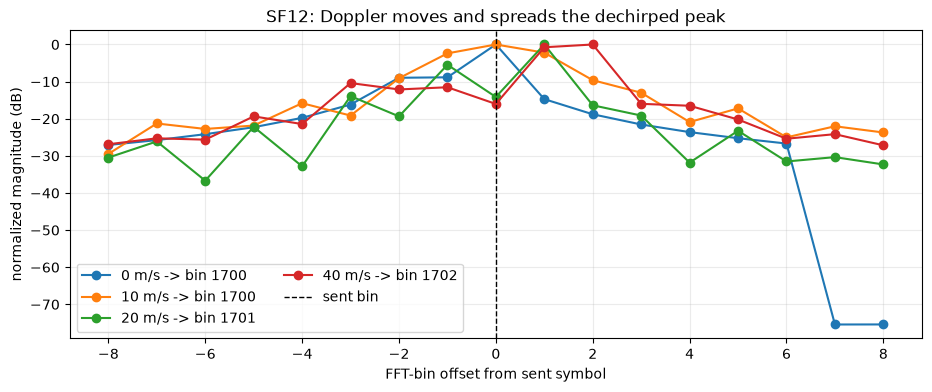

In [12]:
sf = 12
symbol = 1700
fig, ax = plt.subplots(figsize=(11, 4))

for speed in (0, 10, 20, 40):
    sent, detected, spectrum, _ = run_batch(sf, speed, snr_db=None, fixed_symbol=symbol, seed=4)
    magnitude = torch.abs(spectrum[0]).detach().cpu().numpy()
    magnitude_db = 20 * np.log10(np.maximum(magnitude / magnitude.max(), 1e-12))
    offset = np.arange(len(magnitude_db)) - symbol
    neighborhood = np.abs(offset) <= 8
    ax.plot(offset[neighborhood], magnitude_db[neighborhood], marker="o", label=f"{speed} m/s -> bin {detected.item()}")

ax.axvline(0, color="black", linestyle="--", linewidth=1, label="sent bin")
ax.set(title=f"SF{sf}: Doppler moves and spreads the dechirped peak", xlabel="FFT-bin offset from sent symbol", ylabel="normalized magnitude (dB)")
ax.legend(ncol=2)
plt.show()

This receiver deliberately has no carrier-frequency or Doppler estimator. A practical receiver would estimate and compensate frequency offset. The plot isolates why that synchronization stage matters, especially for long SF12 symbols.

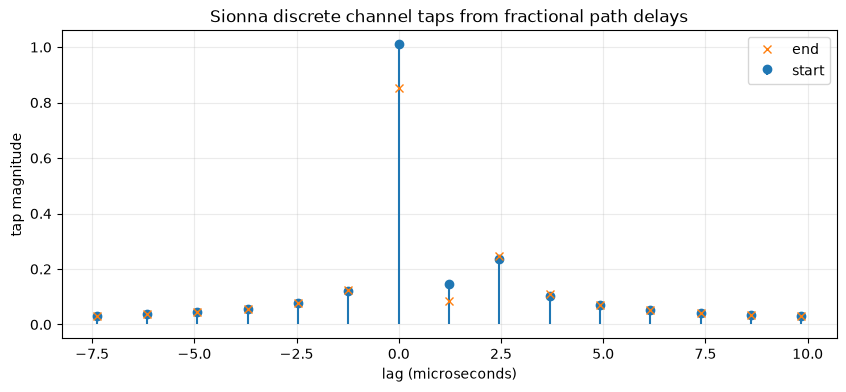

In [13]:
sf = 9
_, _, _, h_time = run_batch(sf, speed_mps=20, snr_db=None, fixed_symbol=100, seed=8)
lags_us = np.arange(L_MIN, L_MAX + 1) / BW_HZ * 1e6
first = torch.abs(h_time[0, 0, 0, 0, 0, 0]).detach().cpu().numpy()
last = torch.abs(h_time[0, 0, 0, 0, 0, -1]).detach().cpu().numpy()

fig, ax = plt.subplots()
ax.stem(lags_us, first, linefmt="C0-", markerfmt="C0o", basefmt=" ", label="start")
ax.plot(lags_us, last, "C1x", label="end")
ax.set(title="Sionna discrete channel taps from fractional path delays", xlabel="lag (microseconds)", ylabel="tap magnitude")
ax.legend()
plt.show()

### A receiver can undo a common frequency offset

The earlier speed sweep leaves Doppler uncompensated. This single-path check applies a known offset of 0.7 FFT bins, then multiplies by its inverse phase rotation. It shows what a synchronization stage is trying to do. A real receiver must estimate that offset from a preamble; one correction cannot remove different Dopplers on multiple paths. UAV speed alone therefore does not set a modem's failure threshold.

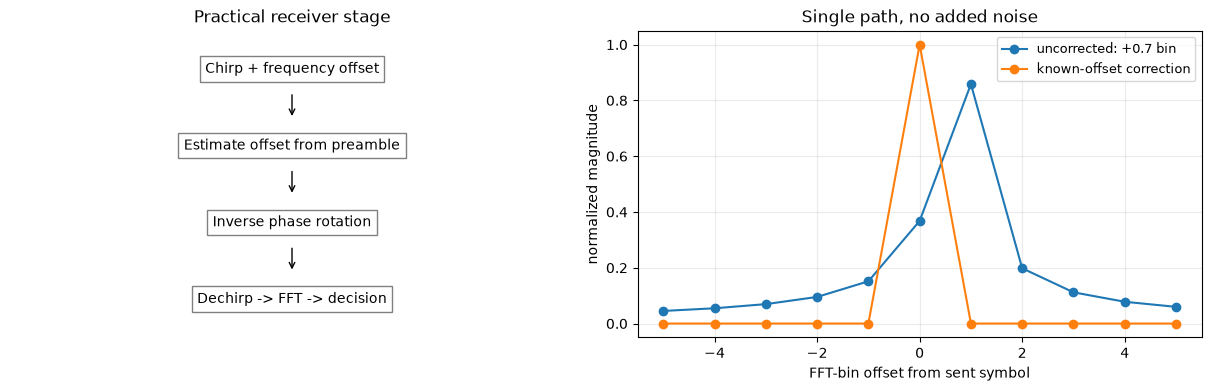

In [14]:
demo_sf, demo_symbol = 9, 100
demo_m = 1 << demo_sf
demo_n = np.arange(demo_m)
demo_reference = reference_upchirp(demo_sf).detach().cpu().numpy()
demo_tx = np.roll(demo_reference, -demo_symbol)
demo_offset_hz = 0.7 * BW_HZ / demo_m
rotation = np.exp(2j * np.pi * demo_offset_hz * demo_n / BW_HZ)
demo_rx = demo_tx * rotation
demo_corrected = demo_rx * rotation.conj()
assert np.allclose(demo_corrected, demo_tx)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
labels = ['Chirp + frequency offset', 'Estimate offset from preamble', 'Inverse phase rotation', 'Dechirp -> FFT -> decision']
for i, label in enumerate(labels):
    y = 3 - i
    axes[0].text(0.5, y, label, ha='center', va='center', bbox=dict(boxstyle='square,pad=0.4', fc='white', ec='0.5'))
    if i < 3:
        axes[0].annotate('', xy=(0.5, y - 0.65), xytext=(0.5, y - 0.3), arrowprops=dict(arrowstyle='->'))
axes[0].set(xlim=(0, 1), ylim=(-0.5, 3.5), title='Practical receiver stage')
axes[0].axis('off')
for samples, label in ((demo_rx, 'uncorrected: +0.7 bin'), (demo_corrected, 'known-offset correction')):
    spectrum = np.abs(np.fft.fft(samples * demo_reference.conj())) / demo_m
    offsets = np.arange(demo_m) - demo_symbol
    keep = np.abs(offsets) <= 5
    axes[1].plot(offsets[keep], spectrum[keep], 'o-', label=label)
axes[1].set(title='Single path, no added noise', xlabel='FFT-bin offset from sent symbol', ylabel='normalized magnitude')
axes[1].legend(fontsize=9)
plt.show()

## 4. Error rate versus UAV speed

The experiment below holds bandwidth, SNR, and average channel energy fixed while changing radial speed. It therefore isolates the interaction between SF and uncompensated Doppler. The three-path profile is illustrative, not a calibrated UAV channel.

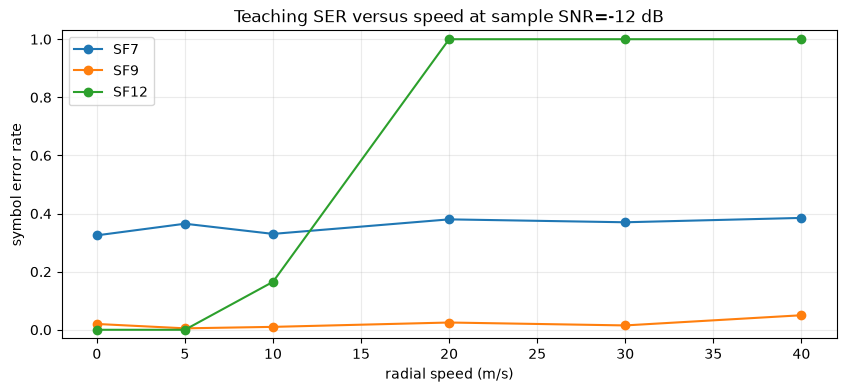

In [15]:
TRIALS = 200
SNR_DB = -12
TEST_SPEEDS = np.array([0, 5, 10, 20, 30, 40])
results = {}

for sf in (7, 9, 12):
    values = []
    for i, speed in enumerate(TEST_SPEEDS):
        sent, detected, _, _ = run_batch(sf, float(speed), SNR_DB, TRIALS, seed=100 * sf + i)
        values.append(float((sent != detected).float().mean().cpu()))
    results[sf] = np.array(values)

fig, ax = plt.subplots()
for sf, ser in results.items():
    ax.plot(TEST_SPEEDS, ser, marker="o", label=f"SF{sf}")
ax.set(title=f"Teaching SER versus speed at sample SNR={SNR_DB} dB", xlabel="radial speed (m/s)", ylabel="symbol error rate", ylim=(-0.03, 1.03))
ax.legend()
plt.show()

## 5. Where Sionna RT belongs

Sionna RT should enter after this tutorial. In a 3D UAV scene it can compute geometry-dependent path gains, delays, angles, blockage, reflections, and motion effects. Those paths can replace PATH_DELAYS_S, PATH_POWERS_DB, and PATH_DIRECTIONS above, then flow through the same Sionna PHY time-channel conversion and LoRa receiver.

Use Sionna PHY here to answer: how does a channel impulse response affect CSS? Use Sionna RT next to answer: what channel impulse response does this city, altitude, trajectory, and antenna geometry produce?

## Takeaways

- Multipath creates delayed chirp copies that spread energy across dechirped FFT bins.
- Doppler is set by carrier frequency and radial velocity, while its impact depends strongly on symbol duration.
- Higher SF improves AWGN sensitivity but can be more sensitive to uncompensated motion during its longer symbol.
- The next RT notebook should replace hand-selected paths with scene-derived paths; it should not replace the LoRa waveform or detector.

## Focused references

- R. Ghanaatian et al., [LoRa Digital Receiver Analysis and Implementation](https://arxiv.org/abs/1811.04146): frequency/timing synchronization and receiver design.
- Sionna [electromagnetics primer](https://nvlabs.github.io/sionna/rt/em_primer.html): complex path coefficients and Doppler, applicable to CSS as well as OFDM.